# 유사도 계산 테스트 (10개 OD)
> OTP 경로 vs 스마트카드 통행 유사도 비교

**목적**: 10개 OD pair에 대해 6-Level 유사도 지표 계산 및 검증

>otp_od_input_filtered 의 od pair로 otp를 돌리고 이에 맞는 od를 TCN_20250218_validated 즉 모든 날짜에 대해서 od 가 맞는 것과 otp결과를 각각 비교해서 7개로 분류한 거에 배정을 해서 확률을 구하는 거야  

---
## 1. 설정

In [1]:
import pandas as pd
import numpy as np
import json
import requests
from requests.adapters import HTTPAdapter
from requests.packages.urllib3.util.retry import Retry
from datetime import datetime
from tqdm import tqdm

import warnings

warnings.filterwarnings('ignore')

In [2]:
%load_ext autoreload
%autoreload 2

from module.similarity import (
    parse_otp_itinerary,
    parse_smartcard_trip,
    deduplicate_itineraries,
    compute_all_metrics,
    compute_composite_similarity,
    match_smartcard_to_otp,
    grade_similarity,
)

---
## 2. 데이터 로드

In [3]:
# OTP OD 입력 데이터 (통행 건수 >= 6인 OD pairs)
od_data = pd.read_csv('../data/otp/input/otp_od_input_filtered.csv')
print(f"총 OD pairs: {len(od_data):,}")
od_data.head()

총 OD pairs: 336,498


,od_pair,o_stop_id,d_stop_id,o_lat,o_lon,d_lat,d_lon,departure_time,trip_count
0,10003_8001060,10003,8001060,37.35292,126.94574,37.36000,126.94823,20250217124616,7
1,10003_8001754,10003,8001754,37.35292,126.94574,37.36555,126.94636,20250217124614,10
2,10003_8001755,10003,8001755,37.35292,126.94574,37.36788,126.94520,20250217045519,9
3,10003_8001757,10003,8001757,37.35292,126.94574,37.37393,126.94234,20250217203534,14
4,10003_8001761,10003,8001761,37.35292,126.94574,37.38452,126.93355,20250217142254,13


In [4]:
# TCN 상세 데이터 (1일치만 로드 - 테스트용)
tcn = pd.read_parquet('../data/tcn/20250217/TCN_20250217_route.parquet')
print(f"TCN 통행 수: {len(tcn):,}")
print(f"TCN 컬럼: {list(tcn.columns)}")

# 컬럼명 확인 (인코딩 깨짐 대비 인덱스 기반 접근)
print(f"\n컬럼 인덱스 매핑:")
for i, col in enumerate(tcn.columns):
    print(f"  {i}: {col}")

TCN 통행 수: 11,981,768
TCN 컬럼: ['group_key', '승차정류장ID', '하차정류장ID', '승차정류장 명칭', '하차정류장 명칭', '승차정류장 X 좌표', '승차정류장 Y 좌표', '하차정류장 X 좌표', '하차정류장 Y 좌표', '승차일시', '하차일시', '교통수단코드', '노선ID', '이용거리', '탑승시간', '숨겨진환승횟수', '숨겨진환승역', '노선명', '교통수단유형', '하차노선명', '하차교통수단유형', '승차정류장순서', '승차누적거리', '하차정류장순서', '하차누적거리', '정류장시퀀스', '정류장명칭시퀀스', '명시적환승횟수', '환승횟수', '총이용거리', '총탑승시간', '노선구간거리', 'transport_category', 'od_pair', 'od_distance']

컬럼 인덱스 매핑:
  0: group_key
  1: 승차정류장ID
  2: 하차정류장ID
  3: 승차정류장 명칭
  4: 하차정류장 명칭
  5: 승차정류장 X 좌표
  6: 승차정류장 Y 좌표
  7: 하차정류장 X 좌표
  8: 하차정류장 Y 좌표
  9: 승차일시
  10: 하차일시
  11: 교통수단코드
  12: 노선ID
  13: 이용거리
  14: 탑승시간
  15: 숨겨진환승횟수
  16: 숨겨진환승역
  17: 노선명
  18: 교통수단유형
  19: 하차노선명
  20: 하차교통수단유형
  21: 승차정류장순서
  22: 승차누적거리
  23: 하차정류장순서
  24: 하차누적거리
  25: 정류장시퀀스
  26: 정류장명칭시퀀스
  27: 명시적환승횟수
  28: 환승횟수
  29: 총이용거리
  30: 총탑승시간
  31: 노선구간거리
  32: transport_category
  33: od_pair
  34: od_distance


---
## 3. 10개 OD pair 선정

기준:
- 통행 건수가 많은 OD
- 다양한 교통수단 조합이 포함된 OD

In [7]:
# 통행 건수 상위 OD 중 TCN에도 존재하는 OD 선택
tcn_od_pairs = set(tcn['od_pair'].unique())
od_data_in_tcn = od_data[od_data['od_pair'].isin(tcn_od_pairs)].copy()
print(f"TCN에도 존재하는 OD pairs: {len(od_data_in_tcn):,}")

# 통행 건수 상위 10개
sample_10 = od_data_in_tcn.nlargest(10, 'trip_count')
print(f"\n선택된 10개 OD:")
print(sample_10[['od_pair', 'o_stop_id', 'd_stop_id', 'trip_count']].to_string())

sample_od_list = sample_10['od_pair'].tolist()

TCN에도 존재하는 OD pairs: 336,498

선택된 10개 OD:
          od_pair  o_stop_id  d_stop_id  trip_count
229484  4211_4213       4211       4213        2434
60284     220_222        220        222        2330
62430     222_228        222        228        2330
62432     222_230        222        230        2291
62419     222_216        222        216        2251
229866  4213_4211       4213       4211        2243
65908     228_222        228        222        2181
66865     230_222        230        222        2051
57971     216_217        216        217        2011
62423     222_220        222        220        1920


---
## 4. OTP 경로 탐색

> docker run -it --rm -p 8080:8080 -e JAVA_TOOL_OPTIONS='-Xmx32g' -v "C:/Folder/Research/simulation/GTX/OTP_A1/data:/var/opentripplanner" docker.io/opentripplanner/opentripplanner:latest --load --serve
    

In [8]:
def get_otp_route(from_lat, from_lon, to_lat, to_lon, date_time=None, port=8080):
    """
    OTP GraphQL API로 경로 탐색
    """
    url = f"http://localhost:{port}/otp/routers/default/index/graphql"
    
    if date_time is None:
        now = datetime.now()
        date = now.strftime("%Y-%m-%d")
        time_str = now.strftime("%H:%M")
    else:
        dt = datetime.strptime(str(date_time), "%Y%m%d%H%M%S")
        date = dt.strftime("%Y-%m-%d")
        time_str = dt.strftime("%H:%M")
    
    query = """
    query ($from: InputCoordinates!, $to: InputCoordinates!, $date: String!, $time: String!, $transportModes: [TransportMode!]) {
        plan(
            from: $from
            to: $to
            date: $date
            time: $time
            transportModes: $transportModes
            numItineraries: 10
            searchWindow: 7200
            walkReluctance: 5.0
            transferPenalty: 0
            walkSpeed: 1.3
        ) {
            itineraries {
                startTime
                endTime
                duration
                walkDistance
                generalizedCost
                legs {
                    mode
                    startTime
                    endTime
                    duration
                    distance
                    generalizedCost
                    from {
                        name
                        lat
                        lon
                        stop { gtfsId id code }
                    }
                    to {
                        name
                        lat
                        lon
                        stop { gtfsId id code }
                    }
                    route {
                        gtfsId
                        longName
                        shortName
                    }
                }
            }
        }
    }
    """
    
    variables = {
        "from": {"lat": from_lat, "lon": from_lon},
        "to": {"lat": to_lat, "lon": to_lon},
        "date": date,
        "time": time_str,
        "transportModes": [{"mode": "TRANSIT"}]
    }
    
    session = requests.Session()
    retry = Retry(connect=3, backoff_factor=0.5)
    adapter = HTTPAdapter(max_retries=retry)
    session.mount('http://', adapter)
    
    response = session.post(url, headers={'Content-Type': 'application/json'},
                           json={'query': query, 'variables': variables})
    
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return None

In [9]:
# 10개 OD에 대해 OTP 경로 탐색
otp_results_raw = {}
otp_results = {}

for _, row in tqdm(sample_10.iterrows(), total=10, desc="OTP 경로탐색"):
    od_pair = row['od_pair']
    result = get_otp_route(
        from_lat=row['o_lat'], from_lon=row['o_lon'],
        to_lat=row['d_lat'], to_lon=row['d_lon'],
        date_time=row['departure_time']
    )
    
    if result and 'data' in result:
        itineraries = result['data']['plan']['itineraries']
        otp_results_raw[od_pair] = itineraries
        
        # 경로 구조 중복 제거 (출발시간만 다른 경로 합침)
        deduped = deduplicate_itineraries(itineraries)
        otp_results[od_pair] = deduped
        print(f"  {od_pair}: {len(itineraries)}개 → {len(deduped)}개 (중복제거)")
    else:
        otp_results_raw[od_pair] = []
        otp_results[od_pair] = []
        print(f"  {od_pair}: 경로 없음")

print(f"\n총 {sum(1 for v in otp_results.values() if v)}개 OD에서 경로 탐색 성공")

OTP 경로탐색:  10%|█         | 1/10 [00:02<00:23,  2.58s/it]

  4211_4213: 10개 → 3개 (중복제거)


OTP 경로탐색:  20%|██        | 2/10 [00:05<00:23,  2.97s/it]

  220_222: 10개 → 5개 (중복제거)


OTP 경로탐색:  30%|███       | 3/10 [00:08<00:19,  2.79s/it]

...

  230_222: 10개 → 1개 (중복제거)


OTP 경로탐색:  90%|█████████ | 9/10 [00:22<00:02,  2.55s/it]

  216_217: 10개 → 4개 (중복제거)


OTP 경로탐색: 100%|██████████| 10/10 [00:25<00:00,  2.57s/it]

  222_220: 10개 → 5개 (중복제거)

총 10개 OD에서 경로 탐색 성공


---
## 5. 스마트카드 통행 추출 (해당 OD)

In [10]:
# 10개 OD에 해당하는 TCN 통행 추출
tcn_sample = tcn[tcn['od_pair'].isin(sample_od_list)].copy()
print(f"해당 OD 통행 수: {len(tcn_sample):,}")
print(f"\nOD별 통행 수:")
print(tcn_sample['od_pair'].value_counts())

해당 OD 통행 수: 22,042

OD별 통행 수:
od_pair
4211_4213    2434
222_228      2330
220_222      2330
222_230      2291
222_216      2251
4213_4211    2243
228_222      2181
230_222      2051
216_217      2011
222_220      1920
Name: count, dtype: int64


In [11]:
# 스마트카드 통행 파싱 테스트 (첫 번째 통행)
test_row = tcn_sample.iloc[0]
sc_parsed = parse_smartcard_trip(test_row)

print("=== 스마트카드 통행 파싱 결과 ===")
for k, v in sc_parsed.items():
    print(f"  {k}: {v}")

=== 스마트카드 통행 파싱 결과 ===
  modes: {'train'}
  transport_category: train_only
  transfer_count: 0
  stops: ['강남', '선릉']
  total_time: 563
  routes: ['2호선']
  od_coords: {'o_lat': 37.498103, 'o_lon': 127.028079, 'd_lat': 37.504487, 'd_lon': 127.048938}


---
## 6. 유사도 계산

In [12]:
# 단일 OD pair 유사도 계산 상세 확인
test_od = sample_od_list[0]
print(f"테스트 OD: {test_od}")

# 해당 OD의 스마트카드 통행 (첫 번째)
sc_trips = tcn_sample[tcn_sample['od_pair'] == test_od]
if len(sc_trips) > 0:
    sc_trip = sc_trips.iloc[100]
    sc_parsed = parse_smartcard_trip(sc_trip)
    
    print(f"\n스마트카드 통행:")
    print(f"  모드: {sc_parsed['modes']}")
    print(f"  환승: {sc_parsed['transfer_count']}회")
    print(f"  정류장: {sc_parsed['stops']}")
    print(f"  총시간: {sc_parsed['total_time']}초 ({sc_parsed['total_time']/60:.1f}분)")
    print(f"  노선: {sc_parsed['routes']}")
    
    # OTP 경로와 비교
    itineraries = otp_results.get(test_od, [])
    if itineraries:
        print(f"\nOTP 경로 수: {len(itineraries)}")
        
        for i, itin in enumerate(itineraries):
            otp_parsed = parse_otp_itinerary(itin)
            metrics = compute_all_metrics(otp_parsed, sc_parsed)
            scores = compute_composite_similarity(metrics)
            
            print(f"\n--- OTP 경로 {i} ---")
            print(f"  모드: {otp_parsed['modes']}")
            print(f"  환승: {otp_parsed['transfer_count']}회")
            print(f"  정류장: {otp_parsed['stops'][:5]}...")
            print(f"  총시간: {otp_parsed['total_time']}초 ({otp_parsed['total_time']/60:.1f}분)")
            print(f"  주노선: {otp_parsed['main_route']}")
            print(f"  \n  유사도 점수:")
            print(f"    복합점수: {scores['composite']:.4f} ({grade_similarity(scores['composite'])})")
            print(f"    모드:     {scores['mode_score']:.4f}")
            print(f"    환승:     {scores['transfer_score']:.4f}")
            print(f"    시퀀스:   {scores['sequence_score']:.4f}")
            print(f"    시간:     {scores['time_score']:.4f}")
            print(f"    노선:     {scores['route_score']:.4f}")
            print(f"    공간:     {scores['spatial_score']:.4f}")
    else:
        print("OTP 경로 없음")
else:
    print("해당 OD의 스마트카드 통행 없음")

테스트 OD: 4211_4213

스마트카드 통행:
  모드: {'train'}
  환승: 0회
  정류장: ['운서', '인천공항1터미널']
  총시간: 712초 (11.9분)
  노선: ['공항철도']

OTP 경로 수: 3

--- OTP 경로 0 ---
  모드: {'train'}
  환승: 0회
  정류장: ['운서', '인천공항1터미널']...
  총시간: 945초 (15.8분)
  주노선: 공항철도
  
  유사도 점수:
    복합점수: 0.9794 (우수)
    모드:     1.0000
    환승:     1.0000
    시퀀스:   1.0000
    시간:     0.8625
    노선:     1.0000
    공간:     1.0000

--- OTP 경로 1 ---
  모드: {'bus'}
  환승: 0회
  정류장: ['롯데마트', '인천공항T1(3층6번)']...
  총시간: 1465초 (24.4분)
  주노선: 223
  
  유사도 점수:
    복합점수: 0.3053 (불량)
    모드:     0.0000
    환승:     1.0000
    시퀀스:   0.0000
    시간:     0.3689
    노선:     0.0000
    공간:     1.0000

--- OTP 경로 2 ---
  모드: {'bus'}
  환승: 0회
  정류장: ['운서역', '인천공항T1(3층6번)']...
  총시간: 1246초 (20.8분)
  주노선: 206
  
  유사도 점수:
    복합점수: 0.3159 (불량)
    모드:     0.0000
    환승:     1.0000
    시퀀스:   0.0000
    시간:     0.4396
    노선:     0.0000
    공간:     1.0000


In [13]:
# test_od 전체 SC 통행 vs OTP 매칭
itineraries = otp_results.get(test_od, [])
sc_trips = tcn_sample[tcn_sample['od_pair'] == test_od]

print(f"OD: {test_od}")
print(f"스마트카드 통행: {len(sc_trips)}건 | OTP 고유 경로: {len(itineraries)}개\n")

# OTP 경로 요약
for i, itin in enumerate(itineraries):
    otp_p = parse_otp_itinerary(itin)
    cnt = itin.get('_count', 1)
    print(f"  [경로 {i}] 모드={otp_p['modes']} 환승={otp_p['transfer_count']}회 "
          f"시간={otp_p['total_time']/60:.1f}분 주노선={otp_p['main_route']} (원본 {cnt}개)")

# 전체 매칭
od_results = []
for _, sc_row in tqdm(sc_trips.iterrows(), total=len(sc_trips), desc=f"{test_od} 매칭"):
    sc_parsed = parse_smartcard_trip(sc_row)
    match_result = match_smartcard_to_otp(sc_parsed, itineraries)
    od_results.append({
        'sc_category': sc_row.get('transport_category', ''),
        'sc_transfers': sc_parsed['transfer_count'],
        'sc_time_min': round(sc_parsed['total_time'] / 60, 1),
        'matched': match_result['matched'],
        'best_score': round(match_result['best_score'], 4),
        'best_grade': match_result['best_grade'],
        'best_otp_idx': match_result['best_idx'],
    })

od_df = pd.DataFrame(od_results)

print(f"\n매칭 성공률: {od_df['matched'].mean()*100:.1f}% ({od_df['matched'].sum()}/{len(od_df)})")
print(f"복합점수 평균: {od_df['best_score'].mean():.4f}")
print(f"\n등급 분포:\n{od_df['best_grade'].value_counts()}")
print(f"\n배정된 OTP 경로 분포:\n{od_df['best_otp_idx'].value_counts().sort_index()}")
print(f"\nSC 카테고리 분포:\n{od_df['sc_category'].value_counts()}")
od_df

OD: 4211_4213
스마트카드 통행: 2434건 | OTP 고유 경로: 3개

  [경로 0] 모드={'train'} 환승=0회 시간=15.8분 주노선=공항철도 (원본 8개)
  [경로 1] 모드={'bus'} 환승=0회 시간=24.4분 주노선=223 (원본 1개)
  [경로 2] 모드={'bus'} 환승=0회 시간=20.8분 주노선=206 (원본 1개)


4211_4213 매칭: 100%|██████████| 2434/2434 [00:00<00:00, 9686.21it/s]


매칭 성공률: 100.0% (2434/2434)
복합점수 평균: 0.9712

등급 분포:
best_grade
우수    2434
Name: count, dtype: int64

배정된 OTP 경로 분포:
best_otp_idx
0    2434
Name: count, dtype: int64

SC 카테고리 분포:
sc_category
train_only    2434
Name: count, dtype: int64


,sc_category,sc_transfers,sc_time_min,matched,best_score,best_grade,best_otp_idx
0,train_only,0,19.4,True,0.9832,우수,0
1,train_only,0,11.8,True,0.9791,우수,0
2,train_only,0,10.9,True,0.9745,우수,0
3,train_only,0,18.0,True,0.9891,우수,0
4,train_only,0,12.2,True,0.9810,우수,0
...,...,...,...,...,...,...,...
2429,train_only,0,12.3,True,0.9819,우수,0
2430,train_only,0,12.8,True,0.9845,우수,0
2431,train_only,0,10.1,True,0.9247,우수,0
2432,train_only,0,15.1,True,0.9966,우수,0


In [14]:
# 배정 결과 요약: OTP 경로별 배정 건수 + 확률 + other
total_sc = len(od_df)
matched_df = od_df[od_df['matched'] == True]
unmatched_df = od_df[od_df['matched'] == False]

# OTP 경로 정보 수집
route_summary = []
for i, itin in enumerate(itineraries):
    otp_p = parse_otp_itinerary(itin)
    assigned = matched_df[matched_df['best_otp_idx'] == i]
    n_assigned = len(assigned)
    prob = n_assigned / total_sc
    
    route_summary.append({
        'route': f"OTP 경로 {i}",
        'mode': ', '.join(sorted(otp_p['modes'])),
        'transfers': otp_p['transfer_count'],
        'main_route': otp_p['main_route'],
        'time_min': round(otp_p['total_time'] / 60, 1),
        'assigned': n_assigned,
        'probability': round(prob, 4),
    })

# other (매칭 안 된 것)
route_summary.append({
    'route': 'other',
    'mode': '-',
    'transfers': '-',
    'main_route': '-',
    'time_min': '-',
    'assigned': len(unmatched_df),
    'probability': round(len(unmatched_df) / total_sc, 4),
})

summary_df = pd.DataFrame(route_summary)

print(f"=== OD: {test_od} 배정 결과 ===")
print(f"총 SC 통행: {total_sc}건\n")
print(summary_df.to_string(index=False))
print(f"\n확률 합계: {summary_df['probability'].sum():.4f}")
summary_df

=== OD: 4211_4213 배정 결과 ===
총 SC 통행: 2434건

   route  mode transfers main_route time_min  assigned  probability
OTP 경로 0 train         0       공항철도     15.8      2434          1.0
OTP 경로 1   bus         0        223     24.4         0          0.0
OTP 경로 2   bus         0        206     20.8         0          0.0
   other     -         -          -        -         0          0.0

확률 합계: 1.0000


,route,mode,transfers,main_route,time_min,assigned,probability
0,OTP 경로 0,train,0,공항철도,15.8,2434,1.0
1,OTP 경로 1,bus,0,223,24.4,0,0.0
2,OTP 경로 2,bus,0,206,20.8,0,0.0
3,other,-,-,-,-,0,0.0


---
## 7. 전체 10개 OD 유사도 계산

In [16]:
# 10개 OD 전체: SC 전건 vs OTP 매칭 + 배정 결과
all_results = []

for od_pair in tqdm(sample_od_list, desc="유사도 계산"):
    itins = otp_results.get(od_pair, [])
    sc_trips = tcn_sample[tcn_sample['od_pair'] == od_pair]
    
    if not itins or len(sc_trips) == 0:
        continue
    
    for _, sc_row in sc_trips.iterrows():
        sc_parsed = parse_smartcard_trip(sc_row)
        match_result = match_smartcard_to_otp(sc_parsed, itins)
        
        all_results.append({
            'od_pair': od_pair,
            'sc_category': sc_row.get('transport_category', ''),
            'sc_transfers': sc_parsed['transfer_count'],
            'sc_time_min': round(sc_parsed['total_time'] / 60, 1),
            'matched': match_result['matched'],
            'best_score': round(match_result['best_score'], 4),
            'best_grade': match_result['best_grade'],
            'best_otp_idx': match_result['best_idx'],
            'mode_score': round(match_result['best_level_scores']['mode_score'], 4),
            'transfer_score': round(match_result['best_level_scores']['transfer_score'], 4),
            'sequence_score': round(match_result['best_level_scores']['sequence_score'], 4),
            'time_score': round(match_result['best_level_scores']['time_score'], 4),
            'route_score': round(match_result['best_level_scores']['route_score'], 4),
            'spatial_score': round(match_result['best_level_scores']['spatial_score'], 4),
        })

results_df = pd.DataFrame(all_results)
print(f"총 비교 건수: {len(results_df):,}")
results_df

유사도 계산: 100%|██████████| 10/10 [00:02<00:00,  4.66it/s]

총 비교 건수: 22,042


,od_pair,sc_category,sc_transfers,sc_time_min,matched,best_score,best_grade,best_otp_idx,mode_score,transfer_score,sequence_score,time_score,route_score,spatial_score
0,4211_4213,train_only,0,19.4,True,0.9832,우수,0,1.0,1.0,1.0,0.8882,1.0,1.0
1,4211_4213,train_only,0,11.8,True,0.9791,우수,0,1.0,1.0,1.0,0.8608,1.0,1.0
2,4211_4213,train_only,0,10.9,True,0.9745,우수,0,1.0,1.0,1.0,0.8301,1.0,1.0
3,4211_4213,train_only,0,18.0,True,0.9891,우수,0,1.0,1.0,1.0,0.9275,1.0,1.0
4,4211_4213,train_only,0,12.2,True,0.9810,우수,0,1.0,1.0,1.0,0.8732,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22037,222_220,train_only,0,5.7,True,0.8298,우수,0,1.0,1.0,1.0,0.8653,0.0,1.0
22038,222_220,train_only,0,10.4,True,0.8322,우수,0,1.0,1.0,1.0,0.8813,0.0,1.0
22039,222_220,train_only,0,6.5,True,0.8367,우수,0,1.0,1.0,1.0,0.9115,0.0,1.0
22040,222_220,train_only,0,5.5,True,0.8275,우수,0,1.0,1.0,1.0,0.8502,0.0,1.0


---
## 8. 결과 요약

=== 복합 점수 통계 ===
count    22042.000000
mean         0.863913
std          0.064415
min          0.215200
25%          0.836100
50%          0.843000
75%          0.849100
max          1.000000
Name: best_score, dtype: float64

등급 분포:
best_grade
우수    21327
양호      623
보통       85
불량        7
Name: count, dtype: int64

=== 임계값별 배정률 ===
  threshold=0.3: 100.0% (22,036/22,042)
  threshold=0.4: 100.0% (22,035/22,042)
  threshold=0.5: 99.7% (21,980/22,042)
  threshold=0.6: 99.6% (21,950/22,042)
  threshold=0.7: 99.6% (21,950/22,042)
  threshold=0.8: 96.8% (21,327/22,042)


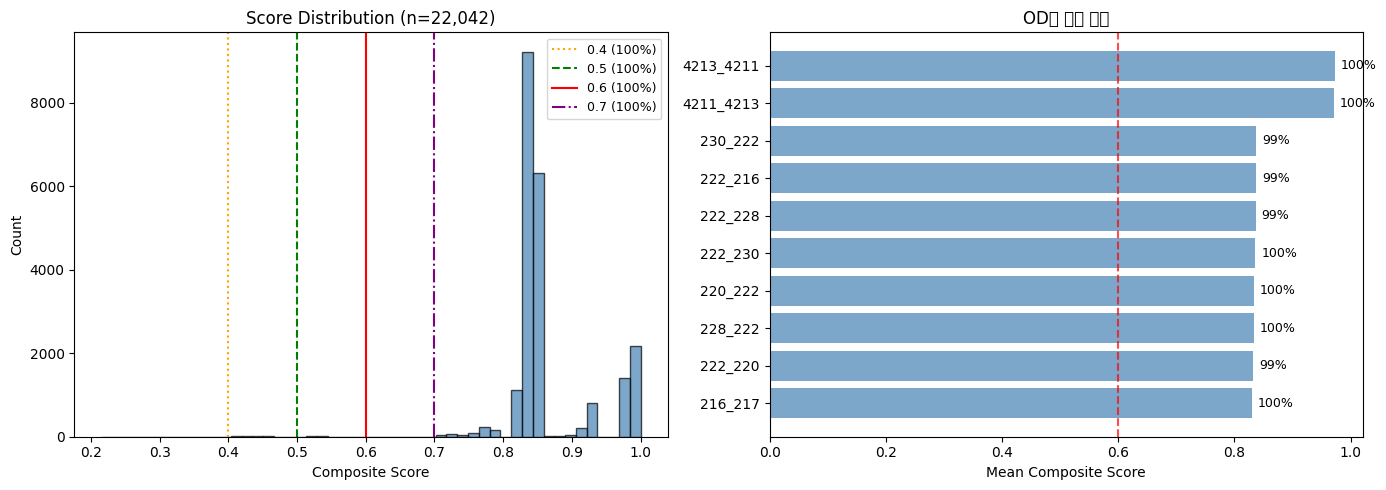

In [17]:
# 점수 분포 확인 + 임계값별 배정률
import matplotlib.pyplot as plt

print("=== 복합 점수 통계 ===")
print(results_df['best_score'].describe())
print(f"\n등급 분포:")
print(results_df['best_grade'].value_counts())

# 임계값별 배정률
print(f"\n=== 임계값별 배정률 ===")
for th in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    rate = (results_df['best_score'] >= th).mean() * 100
    n = (results_df['best_score'] >= th).sum()
    print(f"  threshold={th}: {rate:.1f}% ({n:,}/{len(results_df):,})")

# 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 전체 점수 분포
axes[0].hist(results_df['best_score'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
for th, color, ls in [(0.4, 'orange', ':'), (0.5, 'green', '--'), (0.6, 'red', '-'), (0.7, 'purple', '-.')]:
    rate = (results_df['best_score'] >= th).mean() * 100
    axes[0].axvline(x=th, color=color, linestyle=ls, label=f'{th} ({rate:.0f}%)')
axes[0].set_xlabel('Composite Score')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Score Distribution (n={len(results_df):,})')
axes[0].legend(fontsize=9)

# 2. OD별 평균 점수 + other 비율
od_stats = results_df.groupby('od_pair').agg(
    mean_score=('best_score', 'mean'),
    match_rate_06=('matched', 'mean'),  # threshold=0.6 기준
    total=('best_score', 'count'),
).sort_values('mean_score', ascending=True)

y_pos = range(len(od_stats))
bars = axes[1].barh(y_pos, od_stats['mean_score'], color='steelblue', alpha=0.7)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(od_stats.index)
axes[1].set_xlabel('Mean Composite Score')
axes[1].set_title('OD별 평균 점수')
axes[1].axvline(x=0.6, color='red', linestyle='--', alpha=0.7)

# 바 위에 매칭률 표시
for i, (idx, row) in enumerate(od_stats.iterrows()):
    axes[1].text(row['mean_score'] + 0.01, i, f"{row['match_rate_06']*100:.0f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
# 10개 OD 전체 배정 결과 요약 (경로별 배정 건수 + 확률 + other)
all_summaries = []

for od_pair in sample_od_list:
    itins = otp_results.get(od_pair, [])
    od_sub = results_df[results_df['od_pair'] == od_pair]
    if len(od_sub) == 0:
        continue
    
    total = len(od_sub)
    matched = od_sub[od_sub['matched'] == True]
    unmatched = od_sub[od_sub['matched'] == False]
    
    for i, itin in enumerate(itins):
        otp_p = parse_otp_itinerary(itin)
        n = len(matched[matched['best_otp_idx'] == i])
        all_summaries.append({
            'od_pair': od_pair,
            'route': f"OTP 경로 {i}",
            'mode': ', '.join(sorted(otp_p['modes'])),
            'transfers': otp_p['transfer_count'],
            'main_route': otp_p['main_route'],
            'time_min': round(otp_p['total_time'] / 60, 1),
            'assigned': n,
            'probability': round(n / total, 4),
        })
    
    all_summaries.append({
        'od_pair': od_pair,
        'route': 'other',
        'mode': '-',
        'transfers': '-',
        'main_route': '-',
        'time_min': '-',
        'assigned': len(unmatched),
        'probability': round(len(unmatched) / total, 4),
    })

all_summary_df = pd.DataFrame(all_summaries)

print("=== 10개 OD 배정 결과 ===\n")
for od in sample_od_list:
    sub = all_summary_df[all_summary_df['od_pair'] == od]
    total = sub['assigned'].sum()
    print(f"--- {od} (총 {total}건) ---")
    print(sub[['route', 'mode', 'transfers', 'main_route', 'time_min', 'assigned', 'probability']].to_string(index=False))
    print()

all_summary_df

=== 10개 OD 배정 결과 ===

--- 4211_4213 (총 2434건) ---
   route  mode transfers main_route time_min  assigned  probability
OTP 경로 0 train         0       공항철도     15.8      2434          1.0
OTP 경로 1   bus         0        223     24.4         0          0.0
OTP 경로 2   bus         0        206     20.8         0          0.0
   other     -         -          -        -         0          0.0

--- 220_222 (총 2330건) ---
   route  mode transfers main_route time_min  assigned  probability
OTP 경로 0 train         0      서울2호선      8.0      2319       0.9953
OTP 경로 1   bus         0        146     10.8         0       0.0000
OTP 경로 2   bus         0        740     10.8         0       0.0000
OTP 경로 3   bus         0       2000     11.6         0       0.0000
OTP 경로 4   bus         0       8001     11.6         0       0.0000
   other     -         -          -        -        11       0.0047

--- 222_228 (총 2330건) ---
   route  mode transfers main_route time_min  assigned  probability
OTP 경로 0 tra

,od_pair,route,mode,transfers,main_route,time_min,assigned,probability
0,4211_4213,OTP 경로 0,train,0,공항철도,15.8,2434,1.0000
1,4211_4213,OTP 경로 1,bus,0,223,24.4,0,0.0000
2,4211_4213,OTP 경로 2,bus,0,206,20.8,0,0.0000
3,4211_4213,other,-,-,-,-,0,0.0000
4,220_222,OTP 경로 0,train,0,서울2호선,8.0,2319,0.9953
5,220_222,OTP 경로 1,bus,0,146,10.8,0,0.0000
6,220_222,OTP 경로 2,bus,0,740,10.8,0,0.0000
7,220_222,OTP 경로 3,bus,0,2000,11.6,0,0.0000
8,220_222,OTP 경로 4,bus,0,8001,11.6,0,0.0000
9,220_222,other,-,-,-,-,11,0.0047


=== 레벨별 평균 점수 ===
  mode_score: 0.9998
  transfer_score: 0.9958
  sequence_score: 0.9984
  time_score: 0.8896
  route_score: 0.2122
  spatial_score: 0.9979


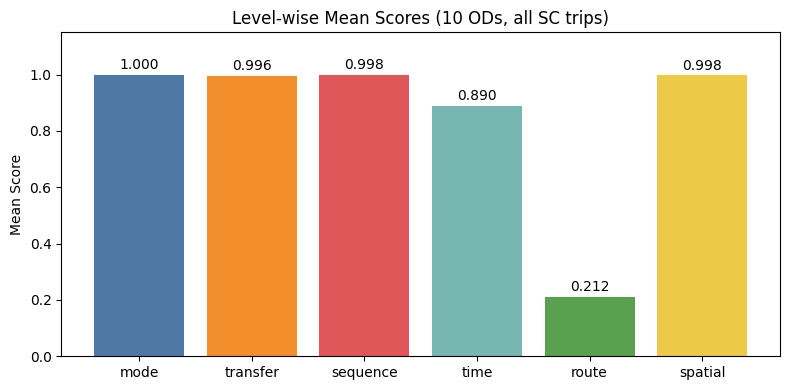

In [19]:
# 레벨별 평균 점수
level_cols = ['mode_score', 'transfer_score', 'sequence_score', 'time_score', 'route_score', 'spatial_score']
print("=== 레벨별 평균 점수 ===")
for col in level_cols:
    print(f"  {col}: {results_df[col].mean():.4f}")

# 레벨별 바 차트
fig, ax = plt.subplots(figsize=(8, 4))
level_means = results_df[level_cols].mean()
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948']
ax.bar(range(len(level_cols)), level_means, color=colors, 
       tick_label=[c.replace('_score','') for c in level_cols])
ax.set_ylabel('Mean Score')
ax.set_title('Level-wise Mean Scores (10 ODs, all SC trips)')
ax.set_ylim(0, 1.15)  
for i, v in enumerate(level_means):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()